# Conceptual framework for graph

accession
|
V
extract metadata
|
V
classify thermal range of metadata -> IF YES -> Return thermal range
| IF NO
V
Extract literature associated with accession
|
V
Classify thermal range based on literature -> IF YES -> Return thermal range
| IF NO
V
Identify host -> IF NO -> Forced classification from metadata -> Return thermal range
|
V
Extract literature associated with host (query search)
|
V
Classify thermal range of host -> IF YES -> Return Thermal range
| IF NO
V
Forced classification using phage metadata

/opt/homebrew/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


download: s3://pmc-oa-opendata/PMC13048485.1/PMC13048485.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13048485.1.txt
download: s3://pmc-oa-opendata/PMC13030558.1/PMC13030558.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13030558.1.txt
download: s3://pmc-oa-opendata/PMC13055312.1/PMC13055312.1.txt to data/accessions/ADI87650/library/accession_lit/PMC13055312.1.txt
download: s3://pmc-oa-opendata/PMC12929629.1/PMC12929629.1.txt to data/accessions/ADI87650/library/accession_lit/PMC12929629.1.txt
download: s3://pmc-oa-opendata/PMC12919812.1/PMC12919812.1.txt to data/accessions/ADI87650/library/accession_lit/PMC12919812.1.txt
download: s3://pmc-oa-opendata/PMC12893549.1/PMC12893549.1.txt to data/accessions/ADI87650/library/accession_lit/PMC12893549.1.txt
No txts or PDFs found for this paper: PMC12874024
CompletedProcess(args='/usr/local/bin/aws --no-sign-request s3 ls s3://pmc-oa-opendata/PMC12874024.1/', returncode=1, stdout='', stderr='')
download: s3://pmc-oa-op

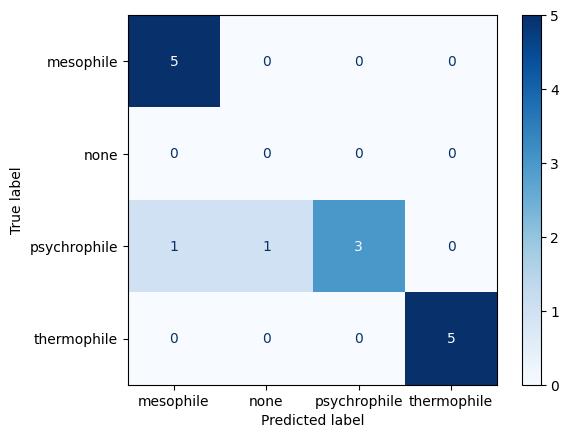

In [1]:
from agents import *
import pandas as pd
import json
from tools import *
import matplotlib.pyplot as plt

# State rows to keep
keep=['accession', 'thermal_range', 'thermal_source', 'thermal_reasoning', 'thermal_confidence', 'thermal_source', 'inference_type', 'thermal_paper', 'host','taxonomic_level','host_reasoning','host_confidence','host_source','host_paper','duration', 'nodes', 'timings']

#Getting accessions
ex_df=pd.read_csv('data/example/example_data.csv')
accessions=ex_df['Accession']


all_df = pd.DataFrame()

# Classifying each accession
for acc in accessions:
    result = MESOTHERMOPSYCHRO(acc, "qwen3.5")
    df = pd.DataFrame([result])

    # serialize complex fields
    df["metadata"] = df["metadata"].apply(json.dumps)
    df["timings"] = df["timings"].apply(json.dumps)
    df["nodes"] = df["nodes"].apply(json.dumps)

    all_df = pd.concat([all_df, df], ignore_index=True)

all_df.to_csv('results/graph/result.csv', index=False)

# Create confusion matrix
actual=ex_df['Thermal Range']
pred=all_df['thermal_range']
plot=ConfusionMatrix(actual, pred)
plot.plot(cmap='Blues')
plt.savefig('results/graph/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [1]:
from agents import *
acc='NP_835731'
MESOTHERMOPSYCHRO(acc, "qwen3.5")

/opt/homebrew/lib/python3.10/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.5.0) or chardet (6.0.0.post1)/charset_normalizer (3.4.4) doesn't match a supported version!
  warnings.warn(
/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model': 'qwen3.5',
 'accession': 'NP_835731',
 'phage': 'Rhodothermus phage RM378',
 'metadata': {'uid': '30044134',
  'accession': 'NP_835731',
  'title': 'RNA polymerase sigma factor [Rhodothermus phage RM378]',
  'organism': 'Rhodothermus phage RM378',
  'taxonId': 148943,
  'sequence_length': 199,
  'create_date': '2003/04/22',
  'update_date': '2023/01/08',
  'dbsource': 'refseq',
  'extra': 'gi|30044134|gnl|REF_NCBI_MICRO|phiN315_144|ref|NP_835731.1|',
  'host': 'Rhodothermus marinus',
  'old_name': 'Bacteriophage RM 378'},
 'host': None,
 'taxonomic_level': None,
 'host_reasoning': None,
 'host_confidence': None,
 'host_source': None,
 'host_found': False,
 'thermal_range': 'thermophile',
 'temperature': None,
 'thermal_reasoning': "The metadata identifies the host organism as 'Rhodothermus marinus'. The genus name 'Rhodothermus' is a strong environmental indicator implying a thermophilic nature (derived from Greek roots related to heat/red heat). According to the inference ru

In [7]:
import pandas as pd
df=pd.read_csv('results/graph/result.csv')
for i in df['thermal_reasoning']:
    print(f'{i}\n\n')

The paper explicitly states that the host bacterium Yersinia pestis EV76 and the phage were maintained and tested at 21 °C, 28 °C, and 37 °C (Section 2.1 and 3.1). The phage exhibited lytic activity and stability across this range, with optimal activity noted at 28 °C. No temperatures below 15 °C or above 45 °C are reported as supporting growth or optimal activity. Since the host Yersinia pestis is a mesophilic pathogen (optimal growth typically 28–37 °C) and the phage functions within this range, the thermal classification is inferred as mesophile based on the explicit temperature range of 21–37 °C where activity is observed.


The paper explicitly states that TXTL reactions were incubated at 29 °C for gene expression, but for phage titration and spotting assays, plates were incubated at 37 °C. Specifically, 'The plates were incubated at 37 °C, facing down, for 4 h' and 'The microplate reader was set to 37 °C'. Additionally, the host bacteria (E. coli B) are standard laboratory strain